## **Welcome!**

This is my new slug monitoring code to get traces of the LLD signals (as square waves). This uses only one other py file, slug_monitor.py (in Core) - below are cells to use the three higher level methods.

## Getting started...

First things first, run the cell below to import the relevant python packages and local files, and to instantiate an instance of SlugMonitor

In [1]:
%matplotlib widget

#sys path imports to find Core folder
import sys
import os

# Adding the repo root to Python path
repo_root = os.path.abspath('..')
sys.path.append(repo_root)

# Imports
from Core.slug_monitor import SlugMonitor
import matplotlib.pyplot as plt 
import pandas as pd

# Instantiate SlugMonitor
sm = SlugMonitor("COM9")

# Plotter 1 - Capture the last *n* seconds of data

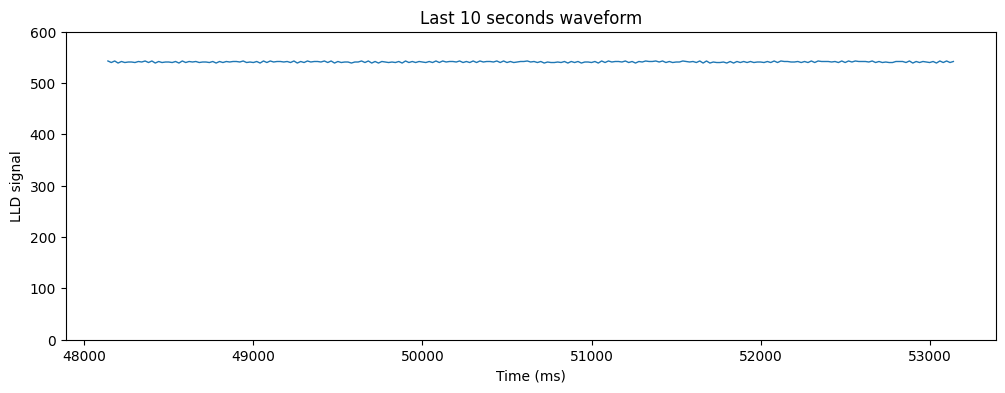

In [4]:
# First, some data is collected before "slicing" it into a window of the last n seconds

# First collect some data, here the last 1000 lines are read
data = sm.read_n(500) 

# Then grab the last 10 (or however many) seconds
times, signals = sm.get_last_seconds(5)

# Finally, plot the figure
plt.figure(figsize=(12,4))
plt.plot(times, signals, lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("LLD signal")
plt.title("Last 10 seconds waveform")
plt.ylim(0, 600)
plt.show()

# Plotter 2 - Stream all readings to a file

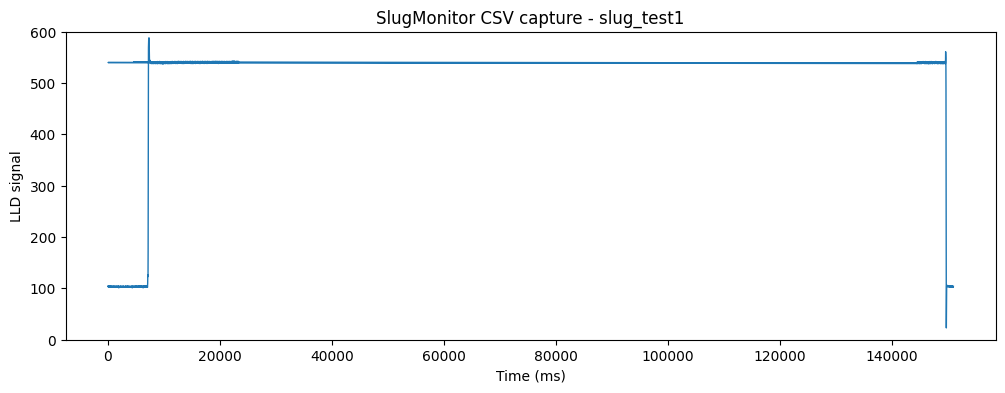

In [2]:
# Stream and save 5000 (or however many) readings to CSV
sm.stream_to_file("Logs/slug_test2.csv", n_lines = 1500)

# Read the CSV file (make sure names match!)
df = pd.read_csv("Logs/slug_test2.csv")

# Plot the data
plt.figure(figsize=(12,4))
plt.plot(df["timestamp_ms"], df["signal"], lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("LLD signal")
plt.title("SlugMonitor CSV capture - slug_test1")
plt.ylim(0, 600)  # maybe not necessary?
plt.show()

In [3]:
print(os.path.abspath("Logs/slug_test.csv"))

C:\Users\CHAD-HPLC\Documents\VictorFlow\Notebooks\Logs\slug_test.csv


# Plotter 3 - Live waveform plotting (use this)

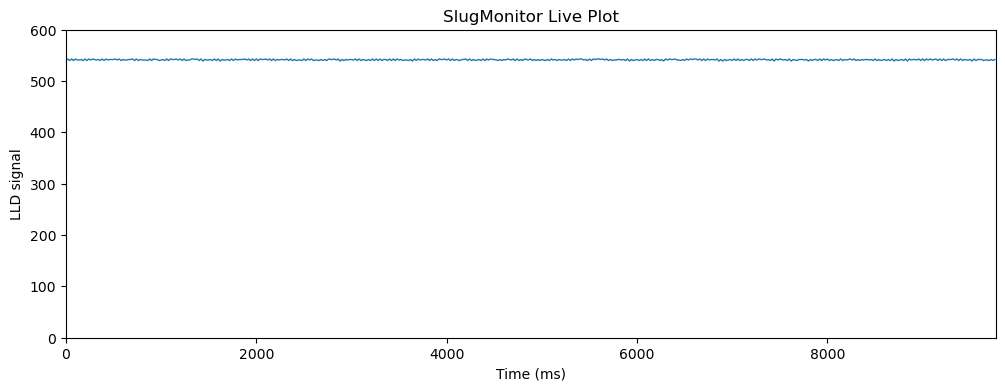

In [2]:
# Plots incoming signals live for the duration set, user can optionally save the data as a CSV by
# providing a csv_filename variable. Otherwise the CSV isnt created.
# From there, the user can run the cell below this one to plot and save the figure

run_name = "slug_test"

csv_path = f"Logs/LLD_CSVs/{run_name}.csv"

times, signals = sm.live_plot(duration = 10, csv_filename=csv_path)

In [ ]:
# To save plot and save the figure saved as a CSV from the live plot:

plt.figure(figsize=(12,4))
plt.plot(times, signals, lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("LLD signal")
plt.title(run_name)
plt.ylim(0,600)
plt.savefig(f"Logs/LLD_plots/{run_name}.png", dpi=300)
plt.show()

In [6]:
# To close the serial connection
sm.close()